In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(
    "superstore.csv",
    encoding='latin1'
)

View Dataset

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Dataset Structure

Dataset Shape

In [8]:
df.shape

(9994, 21)

Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Column Names

In [11]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

# Check Missing Values

In [12]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

# Remove Duplicate Rows

In [13]:
df.duplicated().sum()

0

# Convert Date Column

In [14]:
df['Order Date'] = pd.to_datetime(
    df['Order Date']
)

# Monthly Revenue Trends

Calculate Monthly Revenue

In [17]:
df['Month'] = df['Order Date'].dt.to_period('M')

In [18]:
monthly_sales = df.groupby(
    'Month'
)['Sales'].sum()

print(monthly_sales.head())

Month
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: Sales, dtype: float64


# Plot Monthly Revenue Trend

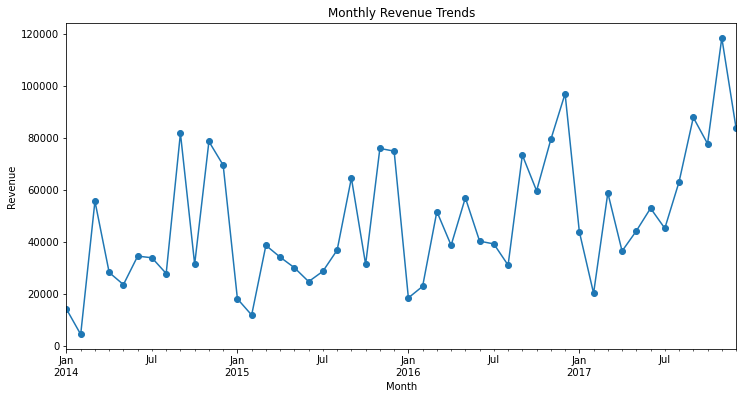

In [19]:
plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker='o'
)

plt.title(
"Monthly Revenue Trends"
)

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

# Top-Selling Products

In [20]:
top_products = df.groupby(
'Product Name'
)['Sales'].sum()\
.sort_values(
ascending=False
).head(10)

In [21]:
print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


Visualization

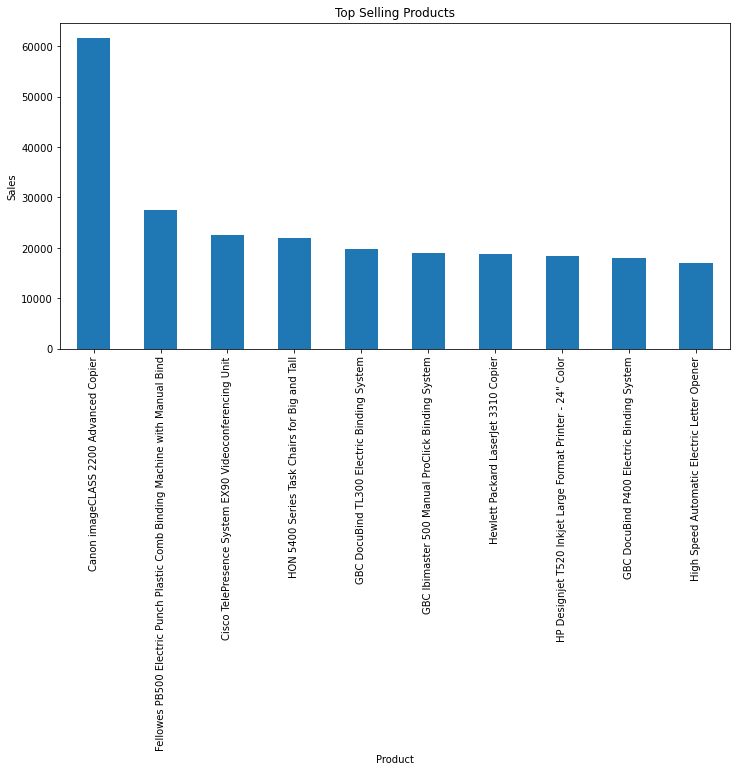

In [22]:
plt.figure(figsize=(12,6))

top_products.plot(
kind='bar'
)

plt.title(
"Top Selling Products"
)

plt.xlabel("Product")

plt.ylabel("Sales")

plt.show()

# Profit Analysis

Total Profit

In [23]:
total_profit = df[
'Profit'
].sum()

print(total_profit)

286397.0217


Profit by Category

In [24]:
profit_category = df.groupby(
'Category'
)['Profit'].sum()

In [25]:
print(profit_category)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


Visualization

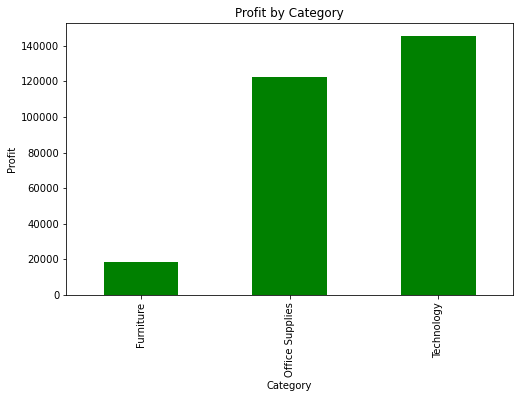

In [27]:
plt.figure(figsize=(8,5))

profit_category.plot(
kind='bar',
color='green'
)

plt.title(
"Profit by Category"
)

plt.xlabel("Category")

plt.ylabel("Profit")

plt.show()

# Sales vs Profit Relationship

# Scatter Plot

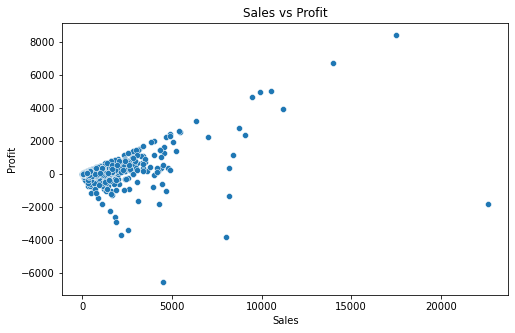

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(

x=df['Sales'],

y=df['Profit']

)

plt.title(
"Sales vs Profit"
)

plt.show()

# Category-wise Sales Analysis

Calculate Category Sales

In [29]:
category_sales = df.groupby(
'Category'
)['Sales'].sum()

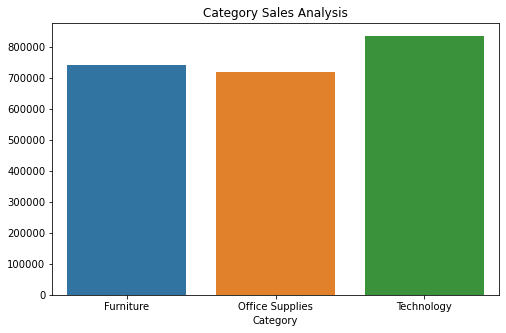

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(

x=category_sales.index,

y=category_sales.values

)

plt.title(
"Category Sales Analysis"
)

plt.show()

# Insight

Insight 1

Monthly revenue changes over time and shows seasonal business variation.

Insight 2

Top products contribute a large share of overall sales.

Insight 3

Some categories generate strong sales but lower profit.

Insight 4

Sales and profit do not always increase together.

# Conclusion

The sales data analysis provided important insights into business performance.

Monthly revenue analysis highlighted revenue trends over time.

Top-selling products were identified based on total sales contribution.

Profit analysis revealed differences across product categories and showed that higher sales do not always lead to higher profitability.

These insights can support better business decision-making and strategy planning.